# 📍 Model 09 — KNN

K-Nearest Neighbors with PCA reduction.


--- MODEL EVALUATION ---
              precision    recall  f1-score   support

           0       0.98      0.93      0.95    113975
           1       0.22      0.58      0.32      4133

    accuracy                           0.91    118108
   macro avg       0.60      0.75      0.64    118108
weighted avg       0.96      0.91      0.93    118108

ROC-AUC: 0.8343
PR-AUC: 0.3863


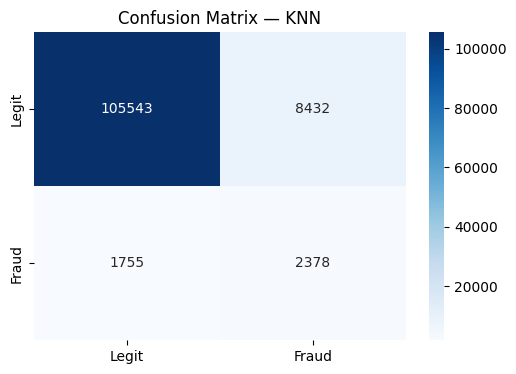

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc, confusion_matrix

# Load and subsample
train = pd.read_csv('../data/train_balanced.csv').sample(50000, random_state=42)
test = pd.read_csv('../data/test.csv')

X_train = train.drop(columns=['isFraud', 'TransactionID'], errors='ignore')
y_train = train['isFraud']
X_test = test.drop(columns=['isFraud', 'TransactionID'], errors='ignore')
y_test = test['isFraud']

# Scale and PCA
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

pca = PCA(n_components=50)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

# Train
model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
model.fit(X_train, y_train)

# Evaluate
probs = model.predict_proba(X_test)[:, 1]
preds = model.predict(X_test)

print("\n--- MODEL EVALUATION ---")
print(classification_report(y_test, preds))
print(f"ROC-AUC: {roc_auc_score(y_test, probs):.4f}")
precision, recall, _ = precision_recall_curve(y_test, probs)
print(f"PR-AUC: {auc(recall, precision):.4f}")

# Plot
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.title('Confusion Matrix — KNN')
plt.show()